In [20]:
# 房价预测：堆叠集成学习教学案例
# House Price Prediction: Stacking Ensemble Learning Tutorial

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("房价预测：堆叠集成学习教学案例")
print("=" * 60)
print()

# =============================================================================
# 第一部分：数据加载与探索
# =============================================================================

def load_and_explore_data(train_path, test_path):
    """
    数据加载与基本探索
    
    教学要点：
    1. 了解数据的基本结构
    2. 检查数据质量问题
    3. 理解目标变量的分布特征
    """
    print("📊 步骤1：数据加载与探索")
    print("-" * 40)
    
    # 加载数据
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)
    
    print(f"✓ 训练集大小: {train_data.shape}")
    print(f"✓ 测试集大小: {test_data.shape}")
    print(f"✓ 特征数量: {train_data.shape[1] - 1}")  # 减去目标变量
    
    # 数据质量检查
    print("\n📋 数据质量检查:")
    missing_counts = train_data.isnull().sum()
    missing_features = missing_counts[missing_counts > 0].sort_values(ascending=False)
    print(f"✓ 有缺失值的特征数: {len(missing_features)}")
    if len(missing_features) > 0:
        print("前5个缺失最多的特征:")
        print(missing_features.head())
    
    # 目标变量分析
    print("\n🎯 目标变量分析:")
    print(f"✓ 房价范围: ${train_data['SalePrice'].min():,.0f} - ${train_data['SalePrice'].max():,.0f}")
    print(f"✓ 平均房价: ${train_data['SalePrice'].mean():,.0f}")
    print(f"✓ 中位数房价: ${train_data['SalePrice'].median():,.0f}")
    
    # 检查价格分布的偏态
    from scipy import stats
    skewness = stats.skew(train_data['SalePrice'])
    print(f"✓ 价格分布偏态系数: {skewness:.2f} ({'右偏' if skewness > 0 else '左偏' if skewness < 0 else '正态'})")
    
    if skewness > 1:
        print("💡 提示: 价格分布右偏严重，建议进行对数变换")
    
    return train_data, test_data

# =============================================================================
# 第二部分：数据预处理
# =============================================================================

def preprocess_data_with_explanation(train_data):
    """
    数据预处理（带详细解释）
    
    教学要点：
    1. 特征与目标变量分离
    2. 对数变换的必要性和效果
    3. 训练集/验证集划分的重要性
    """
    print("\n🔧 步骤2：数据预处理")
    print("-" * 40)
    
    # 分离特征和目标变量
    X = train_data.drop('SalePrice', axis=1)
    y = train_data['SalePrice']
    
    print(f"✓ 原始特征矩阵: {X.shape}")
    print(f"✓ 原始目标变量: {y.shape}")
    
    # 对数变换前后对比
    print("\n📈 对数变换效果:")
    original_skew = abs(y.skew())
    y_log = np.log1p(y)  # log1p = log(1+x)，避免log(0)
    log_skew = abs(y_log.skew())
    
    print(f"✓ 原始分布偏态: {original_skew:.3f}")
    print(f"✓ 对数变换后偏态: {log_skew:.3f}")
    print(f"✓ 偏态改善: {((original_skew - log_skew) / original_skew * 100):.1f}%")
    
    # 训练集验证集划分
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_log, test_size=0.2, random_state=42, stratify=None
    )
    
    print(f"\n📊 数据划分结果:")
    print(f"✓ 训练集: {X_train.shape[0]} 样本")
    print(f"✓ 验证集: {X_val.shape[0]} 样本")
    
    return X_train, X_val, y_train, y_val

# =============================================================================
# 第三部分：特征工程
# =============================================================================

def create_preprocessing_pipeline(X_train):
    """
    创建特征预处理管道
    
    教学要点：
    1. 数值特征vs分类特征的不同处理方式
    2. Pipeline的优势和使用方法
    3. 不同预处理策略的选择理由
    """
    print("\n⚙️ 步骤3：特征工程")
    print("-" * 40)
    
    # 特征类型识别
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = X_train.select_dtypes(include=['object']).columns
    
    print(f"✓ 数值特征数量: {len(numeric_features)}")
    print(f"✓ 分类特征数量: {len(categorical_features)}")
    
    # 展示部分特征示例
    print(f"\n📋 特征示例:")
    print(f"数值特征: {list(numeric_features[:5])}")
    print(f"分类特征: {list(categorical_features[:5])}")
    
    # 数值特征预处理管道
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),  # 中位数填充
        ('scaler', StandardScaler())                    # 标准化
    ])
    
    # 分类特征预处理管道
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    # 组合预处理器
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )
    
    print(f"\n💡 预处理策略说明:")
    print(f"✓ 数值特征: 中位数填充 + 标准化")
    print(f"✓ 分类特征: 常数填充 + 独热编码")
    print(f"✓ 使用Pipeline确保训练/测试一致性")
    
    return preprocessor

# =============================================================================
# 第四部分：基模型定义
# =============================================================================

def create_base_models():
    """
    创建基模型
    
    教学要点：
    1. 不同算法的特点和适用场景
    2. 超参数选择的考虑因素
    3. 模型多样性的重要性
    """
    print("\n🤖 步骤4：基模型定义")
    print("-" * 40)
    
    # 定义基模型
    models = {
        'LightGBM': lgb.LGBMRegressor(
            num_leaves=31,
            learning_rate=0.05,
            n_estimators=200,
            random_state=42,
            verbose=-1
        ),
        'XGBoost': XGBRegressor(
            max_depth=3,
            learning_rate=0.1,
            n_estimators=200,
            random_state=42,
            verbosity=0
        ),
        'RandomForest': RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
    }
    
    print("✓ 基模型组合:")
    for name, model in models.items():
        print(f"  • {name}: {model.__class__.__name__}")
    
    print(f"\n💡 模型选择理由:")
    print(f"✓ LightGBM: 快速、内存效率高")
    print(f"✓ XGBoost: 强大的梯度提升，泛化能力强")
    print(f"✓ RandomForest: 稳定性好，不易过拟合")
    print(f"✓ 三种不同算法确保模型多样性")
    
    return list(models.values())

# =============================================================================
# 第五部分：堆叠集成实现
# =============================================================================

def create_stacking_ensemble(X_train, y_train, preprocessor, base_models):
    """
    实现堆叠集成学习
    
    教学要点：
    1. 什么是堆叠集成
    2. 交叉验证避免数据泄露的重要性
    3. 元学习器的作用
    """
    print("\n🔄 步骤5：堆叠集成学习")
    print("-" * 40)
    
    print("💡 堆叠集成原理:")
    print("✓ 第一层: 基模型通过交叉验证生成预测")
    print("✓ 第二层: 元模型学习如何组合基模型预测")
    print("✓ 避免数据泄露: 使用交叉验证生成元特征")
    
    # 创建基模型管道
    base_pipes = []
    for i, model in enumerate(base_models):
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        base_pipes.append(pipe)
    
    # 交叉验证生成元特征
    print(f"\n🔀 交叉验证生成元特征:")
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    meta_features = np.zeros((X_train.shape[0], len(base_models)))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"✓ 处理第 {fold + 1}/5 折...")
        
        X_train_fold = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_train_fold = y_train.iloc[train_idx]
        
        # 训练基模型并生成预测
        for i, pipe in enumerate(base_pipes):
            pipe.fit(X_train_fold, y_train_fold)
            meta_features[val_idx, i] = pipe.predict(X_val_fold)
    
    print(f"✓ 元特征矩阵生成完成: {meta_features.shape}")
    
    # 训练元模型
    print(f"\n🎯 元模型训练:")
    scaler = StandardScaler()
    meta_features_scaled = scaler.fit_transform(meta_features)
    
    meta_model = Ridge(alpha=1.0, random_state=42)
    meta_model.fit(meta_features_scaled, y_train)
    
    print(f"✓ 元模型: {meta_model.__class__.__name__}")
    print(f"✓ 正则化参数: {meta_model.alpha}")
    
    # 重新训练基模型（使用全部训练数据）
    print(f"\n🔄 基模型最终训练:")
    for i, pipe in enumerate(base_pipes):
        pipe.fit(X_train, y_train)
        print(f"✓ 模型 {i+1} 训练完成")
    
    return base_pipes, meta_model, scaler

# =============================================================================
# 第六部分：模型评估
# =============================================================================

def comprehensive_evaluation(base_pipes, meta_model, scaler, X_val, y_val):
    """
    全面的模型评估
    
    教学要点：
    1. 不同评估指标的含义
    2. 基模型vs集成模型的性能对比
    3. 可视化评估结果
    """
    print("\n📊 步骤6：模型评估")
    print("-" * 40)
    
    # 获取基模型预测
    base_predictions = []
    model_names = ['LightGBM', 'XGBoost', 'RandomForest']
    
    print("🔍 基模型性能:")
    for i, (pipe, name) in enumerate(zip(base_pipes, model_names)):
        pred = pipe.predict(X_val)
        base_predictions.append(pred)
        
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        r2 = r2_score(y_val, pred)
        
        print(f"✓ {name}:")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  R²: {r2:.4f}")
    
    # 集成模型预测
    test_meta = np.column_stack(base_predictions)
    test_meta_scaled = scaler.transform(test_meta)
    ensemble_pred = meta_model.predict(test_meta_scaled)
    
    # 集成模型评估
    ensemble_rmse = np.sqrt(mean_squared_error(y_val, ensemble_pred))
    ensemble_r2 = r2_score(y_val, ensemble_pred)
    
    print(f"\n🎯 集成模型性能:")
    print(f"✓ RMSE: {ensemble_rmse:.4f}")
    print(f"✓ R²: {ensemble_r2:.4f}")
    
    # 性能提升分析
    best_base_rmse = min([np.sqrt(mean_squared_error(y_val, pred)) for pred in base_predictions])
    improvement = (best_base_rmse - ensemble_rmse) / best_base_rmse * 100
    
    print(f"\n📈 性能提升:")
    print(f"✓ 最佳基模型RMSE: {best_base_rmse:.4f}")
    print(f"✓ 集成模型RMSE: {ensemble_rmse:.4f}")
    print(f"✓ 性能提升: {improvement:.2f}%")
    
    return ensemble_pred, base_predictions

# =============================================================================
# 第七部分：结果可视化
# =============================================================================

def create_visualizations(y_val, ensemble_pred, base_predictions, model_names=['LightGBM', 'XGBoost', 'RandomForest']):
    """
    创建教学可视化图表
    
    教学要点：
    1. 预测vs实际值的关系
    2. 残差分析
    3. 模型性能对比
    """
    print("\n📈 步骤7：结果可视化")
    print("-" * 40)
    
    # 设置图表样式
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Evaluation results of the house price prediction model', fontsize=16, fontweight='bold')
    
    # 1. 预测vs实际值散点图
    ax1 = axes[0, 0]
    ax1.scatter(y_val, ensemble_pred, alpha=0.6, color='blue', s=30)
    ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    ax1.set_xlabel('Actual Value (log scale)')
    ax1.set_ylabel('Predicted value (log scale)')
    ax1.set_title('Ensemble Model: Prediction vs Actual')
    ax1.grid(True, alpha=0.3)
    
    # 2. 残差图
    ax2 = axes[0, 1]
    residuals = y_val - ensemble_pred
    ax2.scatter(ensemble_pred, residuals, alpha=0.6, color='green', s=30)
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel('Predicted value')
    ax2.set_ylabel('Residual')
    ax2.set_title('Residual analysis')
    ax2.grid(True, alpha=0.3)
    
    # 3. 模型性能对比
    ax3 = axes[1, 0]
    rmse_scores = []
    all_names = model_names + ['Ensemble']
    all_predictions = base_predictions + [ensemble_pred]
    
    for pred in all_predictions:
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        rmse_scores.append(rmse)
    
    bars = ax3.bar(all_names, rmse_scores, color=['lightblue', 'lightgreen', 'lightcoral', 'gold'])
    ax3.set_ylabel('RMSE')
    ax3.set_title('Model performance comparison')
    ax3.tick_params(axis='x', rotation=45)
    
    # 添加数值标签
    for bar, score in zip(bars, rmse_scores):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{score:.4f}', ha='center', va='bottom')
    
    # 4. 预测分布对比
    ax4 = axes[1, 1]
    ax4.hist(y_val, bins=30, alpha=0.7, label='Actual Value', color='blue', density=True)
    ax4.hist(ensemble_pred, bins=30, alpha=0.7, label='Predicted value', color='red', density=True)
    ax4.set_xlabel(' House Price (log scale)')
    ax4.set_ylabel('Density')
    ax4.set_title('Predicted Distribution vs Actual Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ 可视化图表生成完成")

# =============================================================================
# 第八部分：教学总结和要点
# =============================================================================

def print_learning_summary():
    """
    打印学习要点总结
    """
    print("\n" + "="*60)
    print("📚 学习要点总结")
    print("="*60)
    
    print("\n🎯 核心概念:")
    print("✓ 堆叠集成学习 (Stacking Ensemble)")
    print("✓ 交叉验证避免数据泄露")
    print("✓ 元学习器 (Meta-learner)")
    print("✓ 模型多样性的重要性")
    
    print("\n🔧 技术要点:")
    print("✓ 数据预处理管道 (Pipeline)")
    print("✓ 特征工程策略")
    print("✓ 对数变换处理偏态分布")
    print("✓ 交叉验证的正确使用")
    
    print("\n📊 评估方法:")
    print("✓ RMSE和R²指标")
    print("✓ 残差分析")
    print("✓ 可视化评估")
    print("✓ 基模型vs集成模型对比")
    
    print("\n💡 实践建议:")
    print("✓ 选择多样化的基模型")
    print("✓ 使用简单的元学习器")
    print("✓ 注意数据泄露问题")
    print("✓ 进行充分的可视化分析")

房价预测：堆叠集成学习教学案例



In [21]:
# 数据加载与探索
train_data, test_data = load_and_explore_data('train.csv', 'test.csv')

📊 步骤1：数据加载与探索
----------------------------------------
✓ 训练集大小: (1460, 81)
✓ 测试集大小: (1459, 80)
✓ 特征数量: 80

📋 数据质量检查:
✓ 有缺失值的特征数: 19
前5个缺失最多的特征:
PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
dtype: int64

🎯 目标变量分析:
✓ 房价范围: $34,900 - $755,000
✓ 平均房价: $180,921
✓ 中位数房价: $163,000
✓ 价格分布偏态系数: 1.88 (右偏)
💡 提示: 价格分布右偏严重，建议进行对数变换


In [22]:
# 数据预处理
X_train, X_val, y_train, y_val = preprocess_data_with_explanation(train_data)


🔧 步骤2：数据预处理
----------------------------------------
✓ 原始特征矩阵: (1460, 80)
✓ 原始目标变量: (1460,)

📈 对数变换效果:
✓ 原始分布偏态: 1.883
✓ 对数变换后偏态: 0.121
✓ 偏态改善: 93.6%

📊 数据划分结果:
✓ 训练集: 1168 样本
✓ 验证集: 292 样本


In [23]:
# 特征工程
preprocessor = create_preprocessing_pipeline(X_train)


⚙️ 步骤3：特征工程
----------------------------------------
✓ 数值特征数量: 37
✓ 分类特征数量: 43

📋 特征示例:
数值特征: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual']
分类特征: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour']

💡 预处理策略说明:
✓ 数值特征: 中位数填充 + 标准化
✓ 分类特征: 常数填充 + 独热编码
✓ 使用Pipeline确保训练/测试一致性


In [24]:
# 基模型定义
base_models = create_base_models()


🤖 步骤4：基模型定义
----------------------------------------
✓ 基模型组合:
  • LightGBM: LGBMRegressor
  • XGBoost: XGBRegressor
  • RandomForest: RandomForestRegressor

💡 模型选择理由:
✓ LightGBM: 快速、内存效率高
✓ XGBoost: 强大的梯度提升，泛化能力强
✓ RandomForest: 稳定性好，不易过拟合
✓ 三种不同算法确保模型多样性


In [25]:
# 堆叠集成
base_pipes, meta_model, scaler = create_stacking_ensemble(
    X_train, y_train, preprocessor, base_models
)


🔄 步骤5：堆叠集成学习
----------------------------------------
💡 堆叠集成原理:
✓ 第一层: 基模型通过交叉验证生成预测
✓ 第二层: 元模型学习如何组合基模型预测
✓ 避免数据泄露: 使用交叉验证生成元特征

🔀 交叉验证生成元特征:
✓ 处理第 1/5 折...
✓ 处理第 2/5 折...
✓ 处理第 3/5 折...
✓ 处理第 4/5 折...
✓ 处理第 5/5 折...
✓ 元特征矩阵生成完成: (1168, 3)

🎯 元模型训练:
✓ 元模型: Ridge
✓ 正则化参数: 1.0

🔄 基模型最终训练:
✓ 模型 1 训练完成
✓ 模型 2 训练完成
✓ 模型 3 训练完成


In [26]:
# 模型评估
ensemble_pred, base_predictions = comprehensive_evaluation(
    base_pipes, meta_model, scaler, X_val, y_val
)


📊 步骤6：模型评估
----------------------------------------
🔍 基模型性能:
✓ LightGBM:
  RMSE: 0.1388
  R²: 0.8968
✓ XGBoost:
  RMSE: 0.1330
  R²: 0.9053
✓ RandomForest:
  RMSE: 0.1460
  R²: 0.8858

🎯 集成模型性能:
✓ RMSE: 0.1329
✓ R²: 0.9053

📈 性能提升:
✓ 最佳基模型RMSE: 0.1330
✓ 集成模型RMSE: 0.1329
✓ 性能提升: 0.03%



📈 步骤7：结果可视化
----------------------------------------


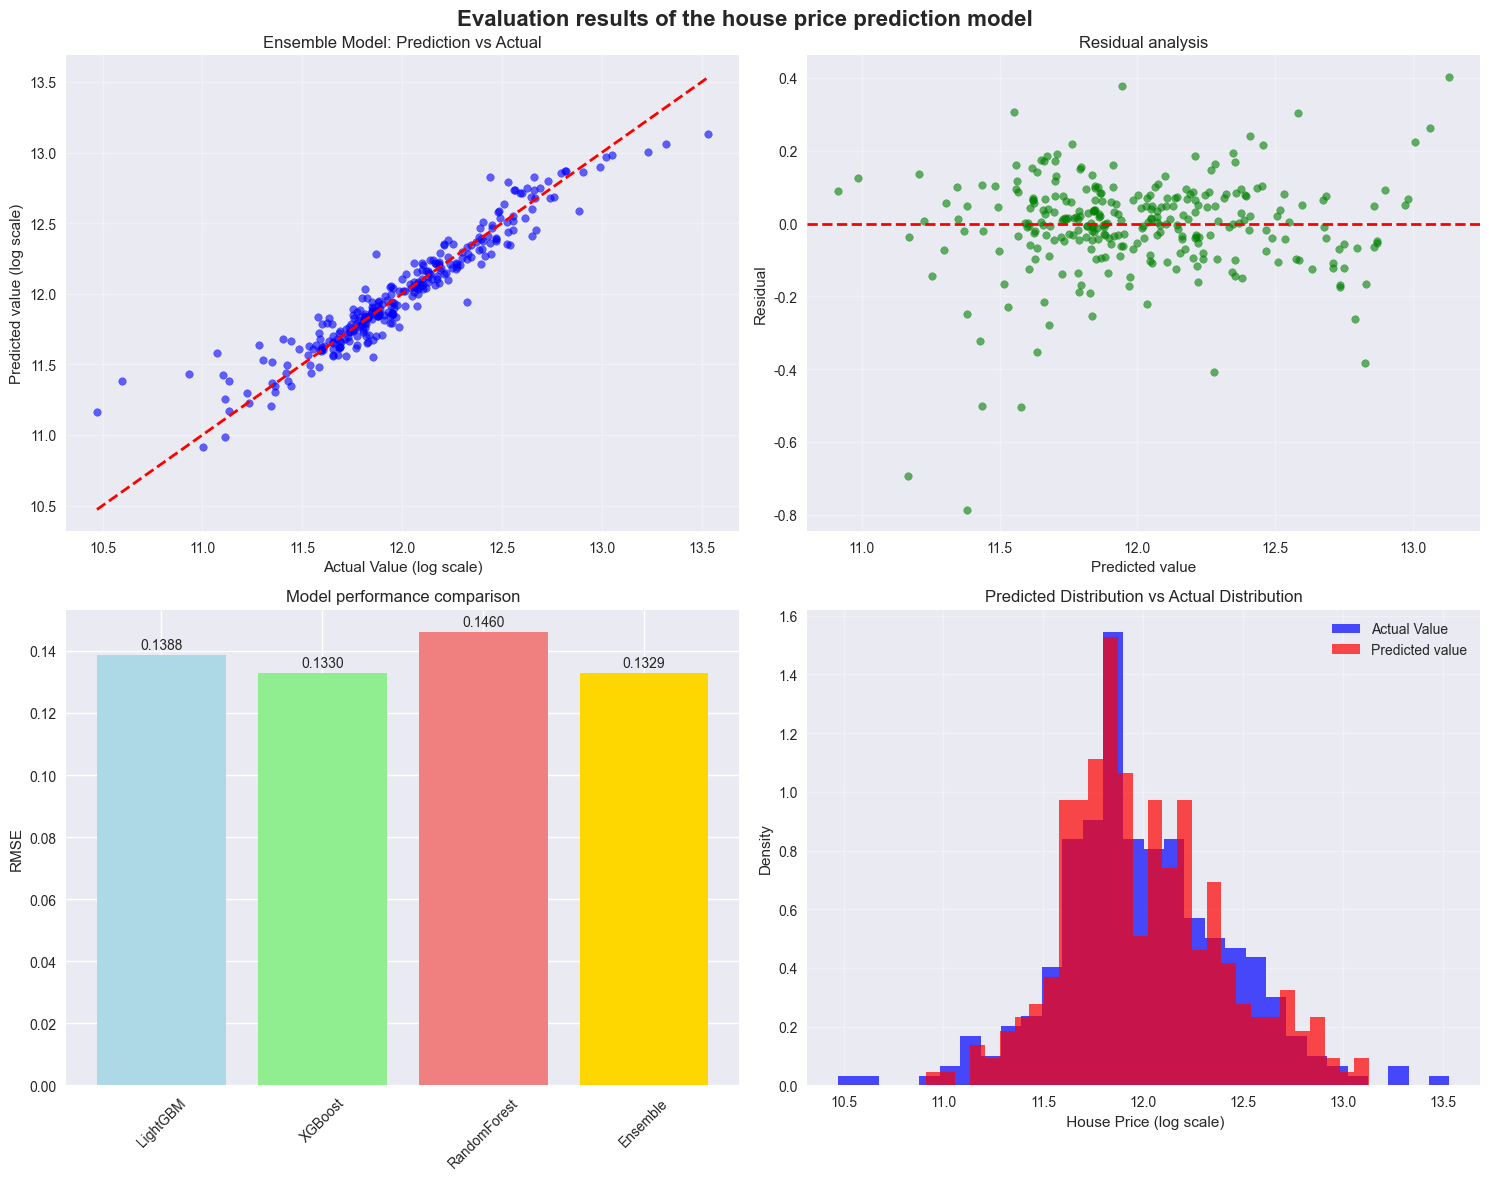

✓ 可视化图表生成完成


In [27]:
# 结果可视化
create_visualizations(y_val, ensemble_pred, base_predictions)

In [28]:
# 学习总结
print_learning_summary()


📚 学习要点总结

🎯 核心概念:
✓ 堆叠集成学习 (Stacking Ensemble)
✓ 交叉验证避免数据泄露
✓ 元学习器 (Meta-learner)
✓ 模型多样性的重要性

🔧 技术要点:
✓ 数据预处理管道 (Pipeline)
✓ 特征工程策略
✓ 对数变换处理偏态分布
✓ 交叉验证的正确使用

📊 评估方法:
✓ RMSE和R²指标
✓ 残差分析
✓ 可视化评估
✓ 基模型vs集成模型对比

💡 实践建议:
✓ 选择多样化的基模型
✓ 使用简单的元学习器
✓ 注意数据泄露问题
✓ 进行充分的可视化分析
